In [42]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import itertools
import os
import random
from tqdm import tqdm
import multiprocessing
from rdkit import Chem

sys.path.append("/home/iscb/wolfson/hagairavid/ligand_aligner")

BIO_LIP_COLUMNS = [
"PDB ID",
"Receptor chain",
"Resolution. '-1.00' stands for lack of resolution information, e.g. for NMR",
"Binding site number code",
"Ligand_ID",
"Ligand_chain",
"Ligand serial number",
"    Binding site residues (with PDB residue numbering)",
"    Binding site residues (with residue re-numbered starting from 1)",
"Catalytic site residues (different sites are separated by ';') (with PDB residue numbering)",
"    Catalytic site residues (different sites are separated by ';') (with residue re-numbered starting from 1)",
"EC number",
"GO terms",
"Binding affinity by manual survey of the original literature. The information in '()' is the PubMed ID",
"Binding affinity provided by the Binding MOAD database. The information in '()' is the ligand information in Binding MOAD",
"Binding affinity provided by the PDBbind-CN database. The information in '()' is the ligand information in PDBbind-CN",
"Binding affinity provided by the BindingDB database",
"UniProt ID",
"PubMed ID",
"Residue sequence number of the ligand (field _atom_site.auth_seq_id in PDBx/mmCIF format)",
"Receptor sequence"]


In [43]:
df = pd.read_csv('/home/iscb/wolfson/hagairavid/databases/BioLiP_nr_0102.txt', sep="\t", header=None, names=BIO_LIP_COLUMNS)
relevant_columns = ["PDB ID", "Receptor chain", "Ligand_ID", "Ligand_chain"]
df = df[relevant_columns].astype('str')

/tmp/ipykernel_1567947/2984452260.py:1: DtypeWarning: Columns (13,14,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/home/iscb/wolfson/hagairavid/databases/BioLiP_nr_0102.txt', sep="\t", header=None, names=BIO_LIP_COLUMNS)


### Ligand metdata file
Contains information regard each ligand, including the SMILE structure that will be later use to count the number of atoms per ligand

In [44]:
tsv_file = 'ligand.tsv.gz'
ligands_df = pd.read_csv(tsv_file, sep='\t', encoding='utf-8', on_bad_lines='skip')
ligands_df.set_index(ligands_df.columns[0], inplace=True)
ligands_df.to_csv('ligands.csv')

### Filter ligands with less than 2 proteins

In [45]:
value_counts = df["Ligand_ID"].value_counts()
values_to_keep = value_counts[value_counts > 1].index
df = df[df["Ligand_ID"].isin(values_to_keep)]

### Leave one ligand chain
Since the goal of this script is to find pairs of proteins that bind the same ligands, there is no need to treat 

In [46]:
df = df[df["Ligand_chain"]=='A']
df.shape

(33561, 4)

## Leave unique ligand chain per ligand

In [47]:
# filtered_df = df.groupby(["Ligand_ID", "PDB ID"]).apply(lambda x: x.loc[x['Receptor chain'].idxmin()])
filtered_df = df.groupby(["Ligand_ID", "PDB ID"]).apply(lambda x: x.loc[x['Ligand_chain'].idxmin()])
filtered_df.shape


/tmp/ipykernel_1567947/2046154261.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  filtered_df = df.groupby(["Ligand_ID", "PDB ID"]).apply(lambda x: x.loc[x['Ligand_chain'].idxmin()])


(23838, 4)

## plot ligand histogram

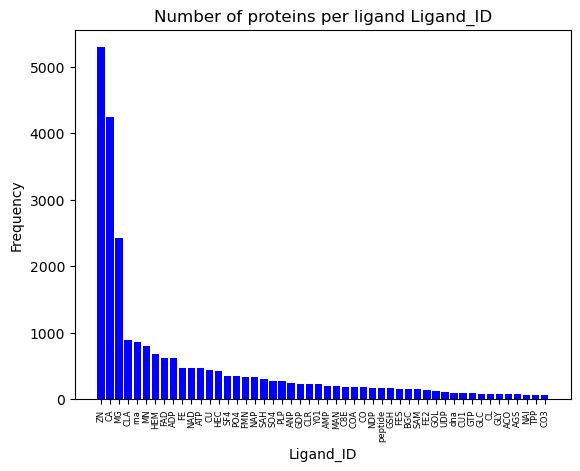

In [48]:
column_to_plot = "Ligand_ID"
value_counts = df[column_to_plot].value_counts()

n_ligands = 50
# Plot the histogram
plt.bar(value_counts.index[:n_ligands], value_counts.values[:n_ligands], color='blue')
plt.xticks(fontsize=6)  
last_bar_height = value_counts.values[:n_ligands][-1]


plt.xticks(rotation=90)

plt.xlabel(column_to_plot)
plt.ylabel('Frequency')
plt.title('Number of proteins per ligand {}'.format(column_to_plot))

# Show plot
plt.show()

In [49]:
value_counts = df["Ligand_ID"].value_counts()
pairs_per_ligand = value_counts.apply(lambda x: x*(x-1)//2)
    
# Compute the total number of pairs
total_pairs = pairs_per_ligand.sum()
print("Total number of pairs:", total_pairs)

Total number of pairs: 28875732


In [50]:
def compute_heavy_atoms(smiles):
        smiles_list = smiles.split(';')
        heavy_atoms_counts = []
        for smi in smiles_list:
            if smi[-1] == ';':
                 smi = smi[:-1]
            mol = Chem.MolFromSmiles(smi.strip())  # Strip whitespace around each SMILES string
            if mol is not None:
                heavy_atoms_counts.append(mol.GetNumHeavyAtoms())
        return heavy_atoms_counts


### Counting number of atoms per ligand

In [51]:
ligand_to_n_atoms = {}
df['n_ligand_atoms'] = pd.NA
for i, ligand_id in tqdm(enumerate(df["Ligand_ID"].unique()), desc="Processing Ligand_IDs"):
    try:
        smiles = ligands_df.loc[ligand_id]['SMILES']
    except KeyError:
        print(f"{ligand_id} is missing from BioLip database.")
        continue
    heavy_atom_count = compute_heavy_atoms(smiles)
    if heavy_atom_count is not None and len(heavy_atom_count) > 0:
        ligand_to_n_atoms[ligand_id] = max(heavy_atom_count)
        df.loc[df['Ligand_ID'] == ligand_id, 'n_ligand_atoms'] = max(heavy_atom_count)

        # df[df["Ligand_ID"] == ligand_id]['n_ligand_atoms'] = max(heavy_atom_count)
        heavy_atom_count = max(heavy_atom_count)
        if heavy_atom_count < 10:
            continue
    else:
        print(f"Could not calculate heavy atom count for ligand {ligand_id}.")
        continue

Processing Ligand_IDs: 0it [00:00, ?it/s][14:04:41] SMILES Parse Error: syntax error while parsing: CC1=C(CCC(O)=O)C2=Cc3n4[Fe]5|6|N2=C1C=c7n5c(=CC8=N|6C(=Cc4c(C)c3CCC(O)=O)C(=C8C=C)C)c(C)c7C=C
[14:04:41] SMILES Parse Error: Failed parsing SMILES 'CC1=C(CCC(O)=O)C2=Cc3n4[Fe]5|6|N2=C1C=c7n5c(=CC8=N|6C(=Cc4c(C)c3CCC(O)=O)C(=C8C=C)C)c(C)c7C=C' for input: 'CC1=C(CCC(O)=O)C2=Cc3n4[Fe]5|6|N2=C1C=c7n5c(=CC8=N|6C(=Cc4c(C)c3CCC(O)=O)C(=C8C=C)C)c(C)c7C=C'
Processing Ligand_IDs: 36it [00:00, 349.87it/s]

nan is missing from BioLip database.
dna is missing from BioLip database.


[14:04:41] Can't kekulize mol.  Unkekulized atoms: 6 7 8 9 10
[14:04:41] Can't kekulize mol.  Unkekulized atoms: 4 5 6 7 8
[14:04:41] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8
Processing Ligand_IDs: 75it [00:00, 369.06it/s][14:04:41] SMILES Parse Error: syntax error while parsing: Cl[Pt+]|1|2|n3ccccc3c4cccc(n|14)c5ccccn|25
[14:04:41] SMILES Parse Error: Failed parsing SMILES 'Cl[Pt+]|1|2|n3ccccc3c4cccc(n|14)c5ccccn|25' for input: 'Cl[Pt+]|1|2|n3ccccc3c4cccc(n|14)c5ccccn|25'
[14:04:41] Can't kekulize mol.  Unkekulized atoms: 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17
Processing Ligand_IDs: 113it [00:00, 369.60it/s][14:04:41] Can't kekulize mol.  Unkekulized atoms: 7 8 15 16 17
[14:04:41] Explicit valence for atom # 34 N, 4, is greater than permitted
[14:04:41] SMILES Parse Error: syntax error while parsing: C[Co++]|12|3|N4=C5C=C6N|1=C([CH](CCC(N)=O)C6(C)C)C(=C7[N-]2=C([CH](CC(N)=O)[C]7(C)CCC(=O)NC[CH](C)O[P](O)(=O)O[CH]8[CH](O)[CH](O[CH]8CO)n9cnc%10cc(C)c(C)cc9%10)[C]%11(C)N|

peptide is missing from BioLip database.
Could not calculate heavy atom count for ligand COB.


[14:04:41] SMILES Parse Error: syntax error while parsing: [Co++]|1|2|3|N4C5=CC6=N|1C(=C(C)C7=N|2[C](C)([CH]8N|3=C(C(=C4[CH](CCC(N)=O)C5(C)C)C)[C](C)(CCC(=O)NC[CH](C)O[P](O)(=O)O[CH]9[CH](O)[CH](O[CH]9CO)n%10cnc%11cc(C)c(C)cc%10%11)[CH]8CC(N)=O)[C](C)(CC(N)=O)[CH]7CCC(N)=O)[C](C)(CC(N)=O)[CH]6CCC(N)=O
[14:04:41] SMILES Parse Error: Failed parsing SMILES '[Co++]|1|2|3|N4C5=CC6=N|1C(=C(C)C7=N|2[C](C)([CH]8N|3=C(C(=C4[CH](CCC(N)=O)C5(C)C)C)[C](C)(CCC(=O)NC[CH](C)O[P](O)(=O)O[CH]9[CH](O)[CH](O[CH]9CO)n%10cnc%11cc(C)c(C)cc%10%11)[CH]8CC(N)=O)[C](C)(CC(N)=O)[CH]7CCC(N)=O)[C](C)(CC(N)=O)[CH]6CCC(N)=O' for input: '[Co++]|1|2|3|N4C5=CC6=N|1C(=C(C)C7=N|2[C](C)([CH]8N|3=C(C(=C4[CH](CCC(N)=O)C5(C)C)C)[C](C)(CCC(=O)NC[CH](C)O[P](O)(=O)O[CH]9[CH](O)[CH](O[CH]9CO)n%10cnc%11cc(C)c(C)cc%10%11)[CH]8CC(N)=O)[C](C)(CC(N)=O)[CH]7CCC(N)=O)[C](C)(CC(N)=O)[CH]6CCC(N)=O'
[14:04:41] SMILES Parse Error: syntax error while parsing: [Co++]|1|2|3|N4C5=CC6=N|1C(=C(C)C7=N|2[C@@](C)([C@@H]8N|3=C(C(=C4[C@@H](CCC(N)=O)C

...

Could not calculate heavy atom count for ligand 08T.


Processing Ligand_IDs: 1772it [00:05, 330.29it/s][14:04:46] Can't kekulize mol.  Unkekulized atoms: 17 18 19 20 21 22 23 24 25
Processing Ligand_IDs: 1843it [00:05, 339.10it/s]

VI4 is missing from BioLip database.
EIF is missing from BioLip database.
WS8 is missing from BioLip database.
A1LYJ is missing from BioLip database.
A1LWZ is missing from BioLip database.
A1D5H is missing from BioLip database.
A1L0S is missing from BioLip database.
A1D8E is missing from BioLip database.
VOA is missing from BioLip database.
A1AN1 is missing from BioLip database.
A1APE is missing from BioLip database.
U1C is missing from BioLip database.


Processing Ligand_IDs: 1896it [00:05, 351.04it/s]

A1IBE is missing from BioLip database.
A1IF6 is missing from BioLip database.
A1IRZ is missing from BioLip database.
A1AIJ is missing from BioLip database.
A1EEB is missing from BioLip database.


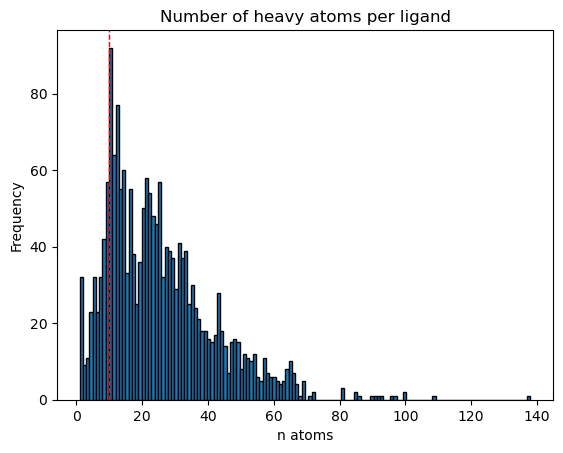

In [52]:
values = list(ligand_to_n_atoms.values())
plt.hist(values, bins=max(values), edgecolor='black')
plt.axvline(x=10, color='red', linestyle='--', linewidth=1, label='Value = 10')

plt.title('Number of heavy atoms per ligand')
plt.xlabel('n atoms')
plt.ylabel('Frequency')
plt.show()

### Filter ligands with less than 10 atoms

In [53]:
df.columns
df = df[df['n_ligand_atoms'] >=10]

## Calculate CATH degree

In [54]:
cath_chains = pd.read_csv('/home/iscb/wolfson/hagairavid/databases/cath-domain-list.txt',sep='\s+', names=['pdb_chain', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k'], skiprows=16)
# cath_chains = cath_chains.set_index('pdb_chain')
cath_chains['domain'] = cath_chains['pdb_chain'].str[-2:]
cath_chains['chain'] = cath_chains['pdb_chain'].str[:-2]

In [55]:
def compare_rows(row1, row2):
    unequal_indices = np.where(row1 != row2)[0]
    if len(unequal_indices) == 0:
        return len(row1)
    else:
        return unequal_indices[0]

In [56]:
def compute_cath_degree(combinations, unique_pairs, result_rows, missing_chains):
    
    for row1, row2 in combinations:
        row1 = row1[1]
        row2 = row2[1]

        if row1['PDB ID'] != row2['PDB ID'] and (row1.iloc[0], row2.iloc[0]) not in unique_pairs and (row2.iloc[0], row1.iloc[0]) not in unique_pairs:
            unique_pairs.add((row1.iloc[0], row2.iloc[0]))
            chain1 = f"{row1['PDB ID']}{row1['Receptor chain']}"
            chain2 = f"{row2['PDB ID']}{row2['Receptor chain']}"

            if chain1 in missing_chains or chain2 in missing_chains:
                continue

            chain1_domains = cath_chains[cath_chains['chain'] == chain1]
            if chain1_domains.empty:
                missing_chains.add(chain1)
                continue

            chain2_domains = cath_chains[cath_chains['chain'] == chain2]
            if chain2_domains.empty:
                missing_chains.add(chain2)
                continue

            max_similarity = -1
            for _, domain1 in chain1_domains.iterrows():
                for _, domain2 in chain2_domains.iterrows():
                    max_similarity = max(max_similarity, compare_rows(domain1.values[1:9], domain2.values[1:9]))

            result_rows.append([row1['PDB ID'], row2['PDB ID'], row1['Receptor chain'], row2['Receptor chain'], row2['Ligand_ID'], max_similarity, heavy_atom_count])
            if len(result_rows) % 10000 == 0:
                print(len(result_rows))

In [58]:
all_combinations = []

for ligand_id, n_atoms in ligand_to_n_atoms.items():
    print(f"Process ligand {ligand_id}, n atoms is  {n_atoms}")
    if n_atoms < 10:
        continue
    filtered_rows = df[df['Ligand_ID'] == ligand_id]
    # print(f"Process ligand {ligand_id}, n chains is  {filtered_rows.shape[0]}")
    
    all_combinations += list(itertools.combinations(filtered_rows.iterrows(), 2))[:10000]

result_rows = multiprocessing.Manager().list()  # Use Manager to create a shared list
missing_chains = set()  
unique_pairs = set() 
    
num_processes = multiprocessing.cpu_count()
chunk_size = max(len(all_combinations) // num_processes, 1)
chunks = [all_combinations[i:i + chunk_size] for i in range(0, len(all_combinations), chunk_size)]
with multiprocessing.Pool(processes=num_processes) as pool:
    pool.starmap(compute_cath_degree, [(chunk, unique_pairs, result_rows, missing_chains) for chunk in chunks])

result_df = pd.DataFrame(list(result_rows), columns=['ref_protein', 'mov_protein', 'ref_chain', 'mov_chain', 'ligand_id', 'CATH_degree', 'ligand_n_atoms'])
# result_df.to_csv(os.path.join('calculated_cath', f'{result_df.shape[0]}_17_07.csv'))

Process ligand SAH, n atoms is  26
Process ligand ASN, n atoms is  9
Process ligand ADP, n atoms is  27
Process ligand HEM, n atoms is  43
Process ligand IPM, n atoms is  12
Process ligand CO, n atoms is  1
Process ligand MN, n atoms is  1
Process ligand ATP, n atoms is  31
Process ligand CA, n atoms is  1
Process ligand CNA, n atoms is  44
Process ligand EST, n atoms is  20
Process ligand NAP, n atoms is  48
Process ligand STR, n atoms is  23
Process ligand HEC, n atoms is  43
Process ligand PGA, n atoms is  9
Process ligand FBP, n atoms is  20
Process ligand PO4, n atoms is  5
Process ligand CU, n atoms is  1
Process ligand AZI, n atoms is  3
Process ligand ZN, n atoms is  1
Process ligand DCF, n atoms is  19
Process ligand COA, n atoms is  48
Process ligand 0GJ, n atoms is  26
Process ligand NAD, n atoms is  44
Process ligand O, n atoms is  1
Process ligand AF3, n atoms is  4
Process ligand SF4, n atoms is  8
Process ligand F3S, n atoms is  7
Process ligand FES, n atoms is  4
Proces

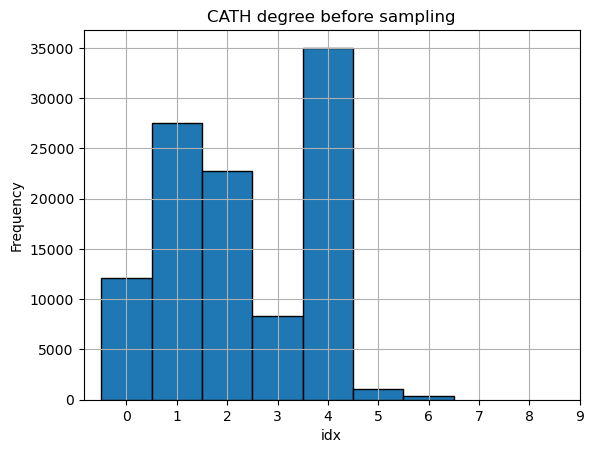

In [59]:
plt.hist(result_df['CATH_degree'], bins=range(8), align='left', edgecolor='black')

plt.xlabel('idx')
plt.ylabel('Frequency')
plt.title('CATH degree before sampling')
plt.xticks(range(10))
plt.grid(True)
plt.show()

In [60]:
result_df.shape


(107244, 7)

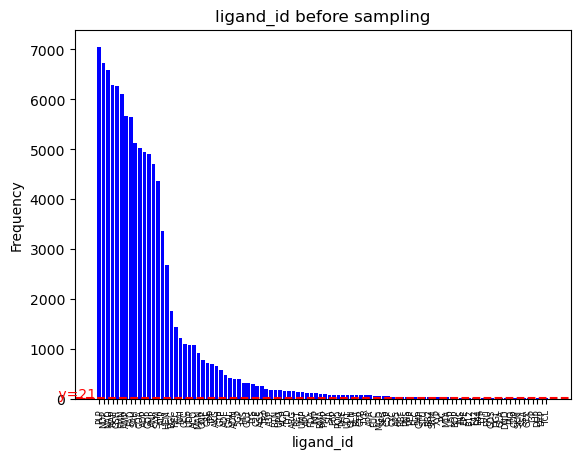

In [61]:
column_to_plot = "ligand_id"
value_counts = result_df[column_to_plot].value_counts()
plt.bar(value_counts.index[:100], value_counts.values[:100], color='blue')
plt.xticks(fontsize=6)  
last_bar_height = value_counts.values[:100][-1]
plt.axhline(y=last_bar_height, color='red', linestyle='--')
plt.text(-10, last_bar_height, f' y={last_bar_height}', color='red', fontsize=10)
plt.xticks(rotation=90)
plt.xlabel(column_to_plot)
plt.ylabel('Frequency')
plt.title(f'{column_to_plot} before sampling')
plt.show()

In [62]:
ligand_freq = result_df['ligand_id'].value_counts()
cath_degree_freq = result_df['CATH_degree'].value_counts()

def calculate_probability(row):
    ligand_prob = 1 / np.sqrt(ligand_freq[row['ligand_id']])
    cath_prob = 1 / np.sqrt(cath_degree_freq[row['CATH_degree']])
    return ligand_prob * cath_prob

result_df['Probability'] = result_df.apply(calculate_probability, axis=1)
result_df['Probability'] /= result_df['Probability'].sum()

print(result_df['Probability'])

0         0.000003
1         0.000003
2         0.000003
3         0.000003
4         0.000003
            ...   
107239    0.000003
107240    0.000003
107241    0.000003
107242    0.000003
107243    0.000002
Name: Probability, Length: 107244, dtype: float64


In [63]:
sampled_rows = np.random.choice(result_df.index, size=result_df.shape[0], replace=False, p=result_df['Probability'])
sampled_df = result_df.loc[sampled_rows]

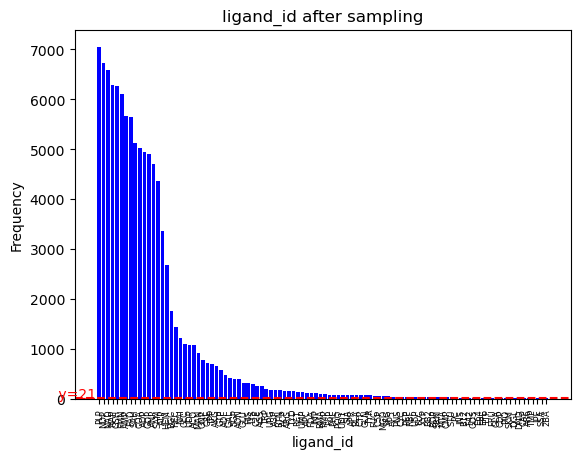

In [64]:
column_to_plot = "ligand_id"
value_counts = sampled_df[column_to_plot].value_counts()

# Plot the histogram
plt.bar(value_counts.index[:100], value_counts.values[:100], color='blue')
plt.xticks(fontsize=6)  # Adjust the font size as per your preference
# Extract the height of the last bar
last_bar_height = value_counts.values[:100][-1]

plt.axhline(y=last_bar_height, color='red', linestyle='--')
plt.text(-10, last_bar_height, f' y={last_bar_height}', color='red', fontsize=10)
plt.xticks(rotation=90)
plt.xlabel(column_to_plot)
plt.ylabel('Frequency')
plt.title(f'{column_to_plot} after sampling')

# Show plot
plt.show()

### Counting number of atoms per ligand

CATH_degree
4    35007
1    27496
2    22794
0    12142
3     8360
5     1037
6      361
8       28
7       19
Name: count, dtype: int64


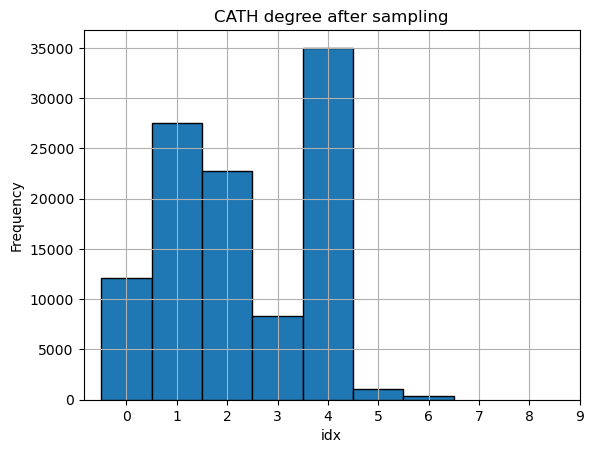

In [65]:

print(sampled_df['CATH_degree'].value_counts())
plt.hist(sampled_df['CATH_degree'], bins=range(8), align='left', edgecolor='black')

plt.xlabel('idx')
plt.ylabel('Frequency')
plt.title('CATH degree after sampling')
plt.xticks(range(10))
plt.grid(True)
plt.show()

In [66]:
import datetime


sampled_df.head()
date = datetime.datetime.now().strftime("%d_%m")
sampled_df.to_csv(os.path.join('calculated_cath',f'sampled_{sampled_df.shape[0]}_{date}.csv'))